In [2]:
import numpy as np 
import pandas as pd 

In [3]:
data = pd.read_csv("cleaned_vulnerability_dataset.csv")

In [4]:
df = pd.DataFrame(data)

In [7]:
print(df.head())

                                     vulnerable_code  \
0  project_loader: do not export empty environmen...   
1  __drm_atomic_helper_crtc_reset(crtc, &cstate->...   
2  "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3  var\tRemarkable = require('remarkable'),\npars...   
4  node.text if node\ncerts['signing'] << cert_no...   

                                          fixed_code  \
0  combined_paths = combine_paths(paths, prepend,...   
1  if (cstate)\n__drm_atomic_helper_crtc_reset(cr...   
2  "THEIA_WEBVIEW_EXTERNAL_ENDPOINT": "${env:THEI...   
3  var\tMarkdownIt = require('markdown-it'),\npar...   
4  Utils.element_text(node)\ncerts['signing'] << ...   

                                                file      language    pattern  
0                tests/unit/test_formatting_utils.py        python  injection  
1           drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c             c       file  
2  packages/plugin-ext/src/main/node/plugin-servi...    typescript  injection  
3     

In [5]:
df.isna().sum()

vulnerable_code    0
fixed_code         0
file               0
language           0
pattern            0
dtype: int64

In [6]:
df["pattern"].unique()

<ArrowStringArray>
[        'injection',              'file',               'xss',
     'sql_injection',           'CWE-352',              'auth',
   'deserialization',          'resource', 'command_injection',
             'error',            'crypto',     'data_exposure',
            'CWE-94',            'config',            'memory',
             'SHORT',           'network']
Length: 17, dtype: str

In [11]:
df['language'].unique()

<StringArray>
[               'python',                     'c',            'typescript',
              'GDScript',          'Transact-SQL',                   'php',
                   'cpp',            'javascript',                 'scdoc',
                  'java',                  'html',                'Python',
             'Text only',                'Carbon',                'Genshi',
                    'go',                   'XML',      'XML+Django/Jinja',
           'Objective-C',                  'Perl',                   'ECL',
                  'ruby',               'verilog',                'QBasic',
       'Tera Term macro',             'Brainfuck',                'Scilab',
                   'css',               'Arduino',                 'MySQL',
        'JavaScript+PHP',               'XML+PHP',                'csharp',
        'ActionScript 3',             'CSS+Lasso',                 'Forth',
                'Matlab',                     'C',                  'SWIG'

In [12]:
import sklearn

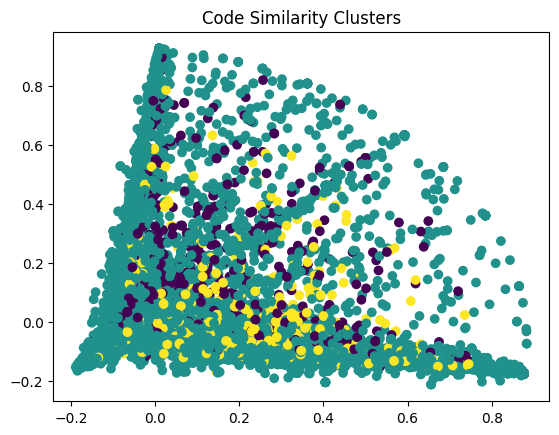

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load your data (assuming it's in a DataFrame)
# df = your dataframe

# Cluster vulnerable code snippets
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X = vectorizer.fit_transform(df['vulnerable_code'].fillna(''))

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['code_cluster'] = kmeans.fit_predict(X)

# Visualize
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
plt.scatter(coords[:, 0], coords[:, 1], c=df['code_cluster'])
plt.title('Code Similarity Clusters')
plt.show()

| Capability | Use Case |
|------------|----------|
| Semantic search | "Find code similar to this vulnerability" |
| Vulnerability classification | Cluster → predict vulnerability type |
| Fix pattern recommendation | Similar vulnerable code → suggest similar fixes |
| Anomaly detection | Code that doesn't fit any cluster |
| Few-shot learning | Use embeddings as features with limited labeled data |